Import modules, define network and apply transformations

In [17]:
import torch
from torchvision.datasets import Flowers102
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, ConcatDataset
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms

class FlowersNetwork(nn.Module):
    def __init__(self, in_channels, out_features, activation_function = F.relu):
        super(FlowersNetwork, self).__init__()

        # Block 1
        self.conv1_1 = nn.Conv2d(in_channels=in_channels, out_channels=32, kernel_size=7, padding=3)
        self.conv1_2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=7, padding=3)  
        self.bn1 = nn.BatchNorm2d(32)

        # Block 2
        self.conv2_1 = nn.Conv2d(32, 64, kernel_size=5, padding=2)
        self.conv2_2 = nn.Conv2d(64, 64, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm2d(64)

        # Block 3
        self.conv3_1 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv3_2 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.conv3_3 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        # Block 4
        self.conv4_1 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.conv4_2 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.conv4_3 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        # Block 5
        self.conv5_1 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.conv5_2 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.conv5_3 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(512)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout1 = nn.Dropout(p=0.75)
        self.dropout2 = nn.Dropout(p=0.5)


        self.fc1 = nn.Linear(512, 1024)
        self.fc2 = nn.Linear(1024, out_features)

        self.activation_function = activation_function

    def forward(self, x):
        # Block 1
        x = self.activation_function(self.conv1_1(x))
        x = self.pool(self.activation_function(self.bn1(self.conv1_2(x))))

        # Block 2
        x = self.activation_function(self.conv2_1(x))
        x = self.pool(self.activation_function(self.bn2(self.conv2_2(x))))

        # Block 3
        x = self.activation_function(self.conv3_1(x))
        x = self.activation_function(self.conv3_2(x))
        x = self.pool(self.activation_function(self.bn3(self.conv3_3(x))))

        # Block 4
        x = self.activation_function(self.conv4_1(x))
        x = self.activation_function(self.conv4_2(x))
        x = self.pool(self.activation_function(self.bn4(self.conv4_3(x))))

        # Block 5
        x = self.activation_function(self.conv5_1(x))
        x = self.activation_function(self.conv5_2(x))
        x = self.pool(self.activation_function(self.bn5(self.conv5_3(x))))
        
        # Fully connected layers
        x = self.global_avg_pool(x)
        x = torch.flatten(x, 1)
        x = self.dropout1(self.activation_function(self.fc1(x)))
        x = self.dropout2(self.fc2(x))
        return x

# Set image dimensions
imageWidth = 224
imageHeight = 224

# Define batch size
batch_size = 32

# Calculate mean and standard deviation of the dataset for normalisation
flowersTransform_no_norm = transforms.Compose([
    transforms.Resize((imageWidth, imageHeight)),
    transforms.ToTensor()
])

flowersTrain_no_norm = Flowers102(root="./data", split="train", download=True, transform=flowersTransform_no_norm)
train_no_norm_loader = DataLoader(flowersTrain_no_norm, batch_size=batch_size, shuffle=False)

mean = 0.
std = 0.
total_samples = 0

for images, _ in train_no_norm_loader:
    batch_samples = images.size(0)
    images = images.view(batch_samples, images.size(1), -1)
    mean += images.mean(2).sum(0)
    std += images.std(2).sum(0)
    total_samples += batch_samples

mean /= total_samples
std /= total_samples

# Apply transformations to dataset
trainingTransform = transforms.Compose([
    transforms.Resize((imageWidth, imageHeight)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

testingTransform = transforms.Compose([
    transforms.Resize((imageWidth, imageHeight)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Combine augmented and original training sets to make 1 large training set
flowersAugmented = Flowers102(root = "./data", split = "train", download=True, transform = trainingTransform)
flowersNormal = Flowers102(root = "./data", split = "train", download=True, transform = testingTransform)
flowersTrain = ConcatDataset([flowersAugmented, flowersNormal])

flowersValidate = Flowers102(root = "./data", split = "val", download=True, transform = testingTransform)
flowersTest = Flowers102(root = "./data", split = "test", download=True, transform = testingTransform)

# Move model onto GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create DataLoaders for batch usage
train_loader = DataLoader(flowersTrain, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(flowersValidate, batch_size=batch_size, shuffle=False)

imageChannels = 3 #R,G,B
imageSize = imageWidth*imageHeight*imageChannels

Initialise classifier, optimiser and loss function. Then train the model, output loss and evaluate accuracy per epoch.

In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score

classifier = FlowersNetwork(in_channels = imageChannels, out_features = 102, activation_function = F.selu)

# Move model to GPU
classifier.to(device)

lossFunction = nn.CrossEntropyLoss()
optimiser = torch.optim.AdamW(classifier.parameters(), lr=0.0001, weight_decay=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min', factor=0.1, patience=5)

epochs = 100
bestLoss = float('inf')
patience = 5
lossTolerance = 1e-4
losses = []
valAccuracies = []
trainAccuracies = []
precisions = []
recalls = []
f1Scores = []
for i in range(epochs):
  print(f"-----Epoch {i+1}-----")
  classifier.train()
  epochLoss = 0.0
  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)

    predictions = classifier.forward(images)

    loss = lossFunction(predictions, labels)
    epochLoss += loss.item()

    optimiser.zero_grad()
    loss.backward()
    optimiser.step()

  # Validation phase
  classifier.eval()
  val_loss = 0.0
  correct = 0
  total = 0
  all_labels = []
  all_preds = []
  with torch.no_grad():
      for images, labels in val_loader:
          images, labels = images.to(device), labels.to(device)
          outputs = classifier(images)
          val_loss += lossFunction(outputs, labels).item()
          _, predicted = torch.max(outputs, 1)
          correct += (predicted == labels).sum().item()
          total += labels.size(0)
          all_labels.extend(labels.cpu().numpy())
          all_preds.extend(predicted.cpu().numpy())

  val_loss /= len(val_loader)
  val_accuracy = correct / total
  print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")
  valAccuracies.append(val_accuracy)

  precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
  recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
  f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
  print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")

  precisions.append(precision)
  recalls.append(recall)
  f1Scores.append(f1)

  scheduler.step(val_loss)

  # Check for overfitting
  classifier.eval()
  train_loss = 0.0
  correct_train = 0
  total_train = 0
  train_data_labels = []
  train_data_preds = []
  with torch.no_grad():
      for images, labels in train_loader:
          images, labels = images.to(device), labels.to(device)
          outputs = classifier(images)
          train_loss += lossFunction(outputs, labels).item()
          _, predicted = torch.max(outputs, 1)
          correct_train += (predicted == labels).sum().item()
          total_train += labels.size(0)
          train_data_labels.extend(labels.cpu().numpy())
          train_data_preds.extend(predicted.cpu().numpy())

  train_loss /= len(train_loader)
  train_accuracy = correct_train / total_train
  print(f"Training Loss: {train_loss:.4f}, Training Set Accuracy: {train_accuracy:.4f}")
  trainAccuracies.append(train_accuracy)

  epochLoss /= len(train_loader)
  losses.append(epochLoss)
  print(f"Epoch Training Loss: {epochLoss:.6f}")
  
  # Check for early stopping
  if epochLoss + lossTolerance < bestLoss:
      bestLoss = epochLoss
      patience = 5
  else:
      patience -= 1
      if patience == 0:
          pass
          #print("Loss hasn't improved for the last few epochs. Stopping training.")
          #break

-----Epoch 1-----
Validation Loss: 4.4792, Validation Accuracy: 0.0333
Precision: 0.0043, Recall: 0.0333, F1 Score: 0.0072
Training Loss: 4.4596, Training Set Accuracy: 0.0436
Epoch Training Loss: 4.822827
-----Epoch 2-----
Validation Loss: 4.3988, Validation Accuracy: 0.0559
Precision: 0.0105, Recall: 0.0559, F1 Score: 0.0164
Training Loss: 4.3786, Training Set Accuracy: 0.0642
Epoch Training Loss: 4.682133
-----Epoch 3-----
Validation Loss: 4.3669, Validation Accuracy: 0.0637
Precision: 0.0378, Recall: 0.0637, F1 Score: 0.0294
Training Loss: 4.3572, Training Set Accuracy: 0.0583
Epoch Training Loss: 4.620125
-----Epoch 4-----
Validation Loss: 4.3530, Validation Accuracy: 0.0657
Precision: 0.0267, Recall: 0.0657, F1 Score: 0.0307
Training Loss: 4.3442, Training Set Accuracy: 0.0721
Epoch Training Loss: 4.594152
-----Epoch 5-----
Validation Loss: 4.2906, Validation Accuracy: 0.0618
Precision: 0.0248, Recall: 0.0618, F1 Score: 0.0259
Training Loss: 4.2691, Training Set Accuracy: 0.0745


KeyboardInterrupt: 

Plot graphs

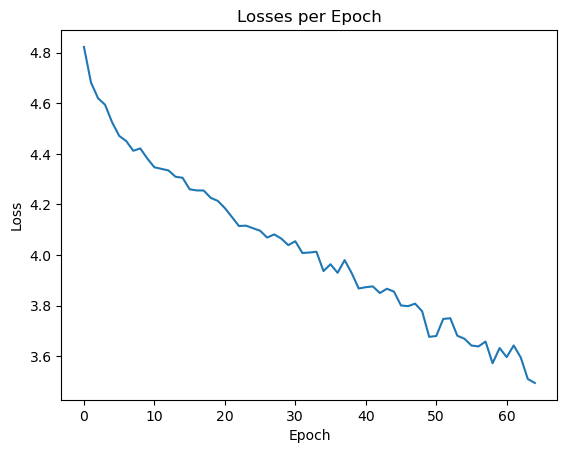

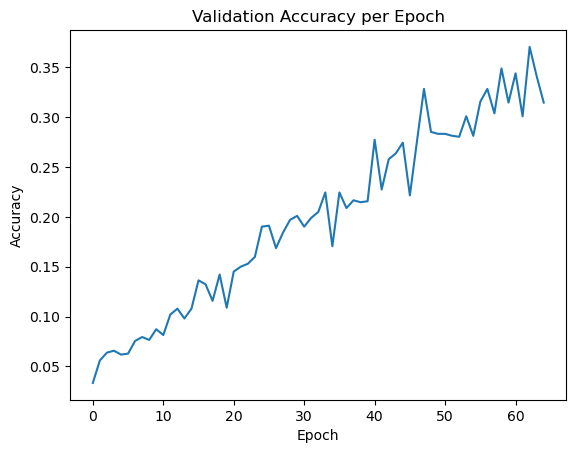

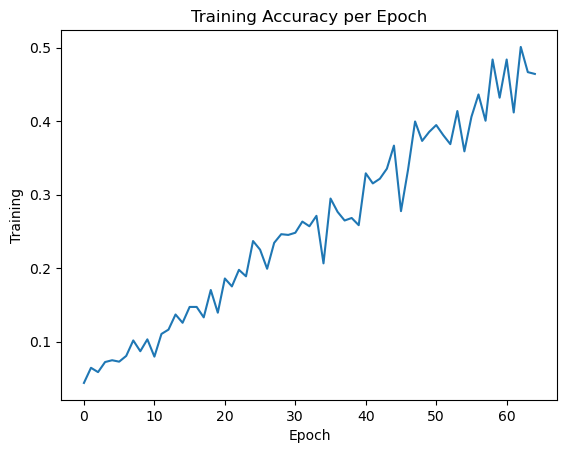

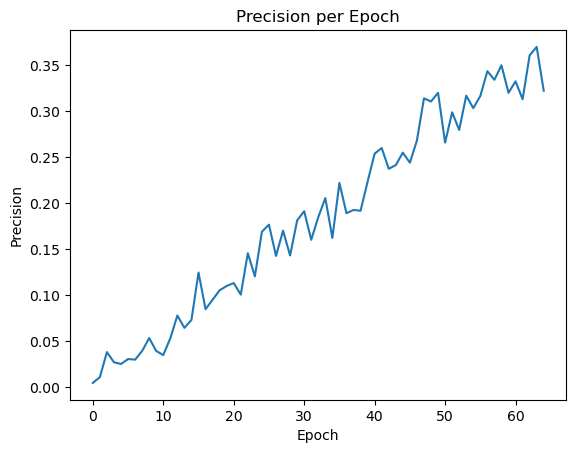

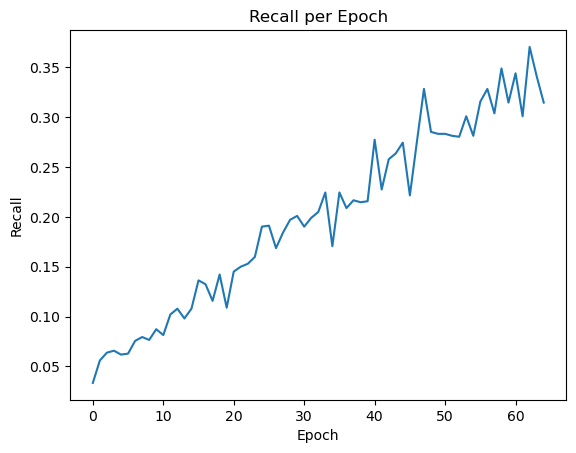

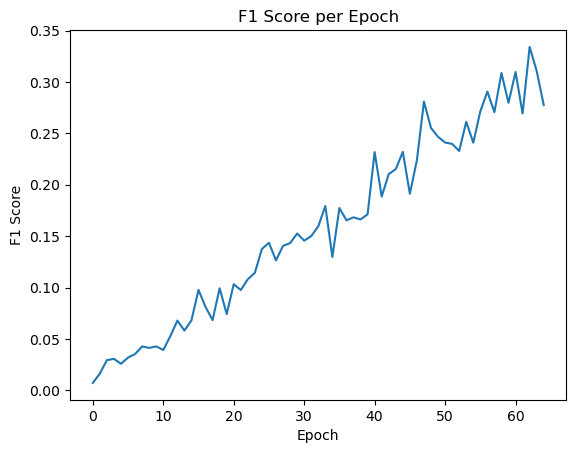

In [19]:
plt.plot(range(len(losses)), losses)
plt.title("Losses per Epoch")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.show()

plt.plot(range(len(valAccuracies)), valAccuracies)
plt.title("Validation Accuracy per Epoch")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.show()

plt.plot(range(len(trainAccuracies)), trainAccuracies)
plt.title("Training Accuracy per Epoch")
plt.ylabel("Training")
plt.xlabel("Epoch")
plt.show()

plt.plot(range(len(precisions)), precisions)
plt.title("Precision per Epoch")
plt.ylabel("Precision")
plt.xlabel("Epoch")
plt.show()

plt.plot(range(len(recalls)), recalls)
plt.title("Recall per Epoch")
plt.ylabel("Recall")
plt.xlabel("Epoch")
plt.show()

plt.plot(range(len(f1Scores)), f1Scores)
plt.title("F1 Score per Epoch")
plt.ylabel("F1 Score")
plt.xlabel("Epoch")
plt.show()

Save model checkpoint

In [22]:
checkpoint = {
    'epoch': epochs + 1,
    'state_dict': classifier.state_dict(),
    'optimiser': optimiser.state_dict(),
    'best_loss': bestLoss,
    'scheduler': scheduler.state_dict()
}

torch.save(checkpoint, 'Attempt6.pth')

Load model checkpoint (if required)

In [ ]:
checkpoint = torch.load('Attempt6.pth')
classifier.load_state_dict(checkpoint['state_dict'])
optimiser.load_state_dict(checkpoint['optimiser'])
epoch = checkpoint['epoch']
bestLoss = checkpoint['best_loss']
scheduler.load_state_dict(checkpoint['scheduler'])

Continue training (if required)

In [23]:
epochs = 100
bestLoss = float('inf')
patience = 5
lossTolerance = 1e-4
losses = []
valAccuracies = []
trainAccuracies = []
precisions = []
recalls = []
f1Scores = []
for i in range(epochs):
  print(f"-----Epoch {i+1}-----")
  classifier.train()
  epochLoss = 0.0
  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)

    predictions = classifier.forward(images)

    loss = lossFunction(predictions, labels)
    epochLoss += loss.item()

    optimiser.zero_grad()
    loss.backward()
    optimiser.step()

  # Validation phase
  classifier.eval()
  val_loss = 0.0
  correct = 0
  total = 0
  all_labels = []
  all_preds = []
  with torch.no_grad():
      for images, labels in val_loader:
          images, labels = images.to(device), labels.to(device)
          outputs = classifier(images)
          val_loss += lossFunction(outputs, labels).item()
          _, predicted = torch.max(outputs, 1)
          correct += (predicted == labels).sum().item()
          total += labels.size(0)
          all_labels.extend(labels.cpu().numpy())
          all_preds.extend(predicted.cpu().numpy())

  val_loss /= len(val_loader)
  val_accuracy = correct / total
  print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")
  valAccuracies.append(val_accuracy)

  precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
  recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
  f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
  print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")

  precisions.append(precision)
  recalls.append(recall)
  f1Scores.append(f1)

  scheduler.step(val_loss)

  # Check for overfitting
  classifier.eval()
  train_loss = 0.0
  correct_train = 0
  total_train = 0
  train_data_labels = []
  train_data_preds = []
  with torch.no_grad():
      for images, labels in train_loader:
          images, labels = images.to(device), labels.to(device)
          outputs = classifier(images)
          train_loss += lossFunction(outputs, labels).item()
          _, predicted = torch.max(outputs, 1)
          correct_train += (predicted == labels).sum().item()
          total_train += labels.size(0)
          train_data_labels.extend(labels.cpu().numpy())
          train_data_preds.extend(predicted.cpu().numpy())

  train_loss /= len(train_loader)
  train_accuracy = correct_train / total_train
  print(f"Training Loss: {train_loss:.4f}, Training Set Accuracy: {train_accuracy:.4f}")
  trainAccuracies.append(train_accuracy)

  epochLoss /= len(train_loader)
  losses.append(epochLoss)
  print(f"Epoch Training Loss: {epochLoss:.6f}")
  
  # Check for early stopping
  if epochLoss + lossTolerance < bestLoss:
      bestLoss = epochLoss
      patience = 5
  else:
      patience -= 1
      if patience == 0:
          pass
          #print("Loss hasn't improved for the last few epochs. Stopping training.")
          #break

-----Epoch 1-----
Validation Loss: 2.9138, Validation Accuracy: 0.3725
Precision: 0.3930, Recall: 0.3725, F1 Score: 0.3430
Training Loss: 2.5836, Training Set Accuracy: 0.5299
Epoch Training Loss: 3.424937
-----Epoch 2-----
Validation Loss: 2.8886, Validation Accuracy: 0.3804
Precision: 0.3965, Recall: 0.3804, F1 Score: 0.3488
Training Loss: 2.5316, Training Set Accuracy: 0.5632
Epoch Training Loss: 3.467277
-----Epoch 3-----
Validation Loss: 2.8523, Validation Accuracy: 0.3833
Precision: 0.3867, Recall: 0.3833, F1 Score: 0.3551
Training Loss: 2.5549, Training Set Accuracy: 0.5397
Epoch Training Loss: 3.398360
-----Epoch 4-----
Validation Loss: 2.8054, Validation Accuracy: 0.4000
Precision: 0.4015, Recall: 0.4000, F1 Score: 0.3690
Training Loss: 2.4504, Training Set Accuracy: 0.5676
Epoch Training Loss: 3.422112
-----Epoch 5-----
Validation Loss: 2.8008, Validation Accuracy: 0.3941
Precision: 0.3887, Recall: 0.3941, F1 Score: 0.3642
Training Loss: 2.4431, Training Set Accuracy: 0.5843


Update graphs

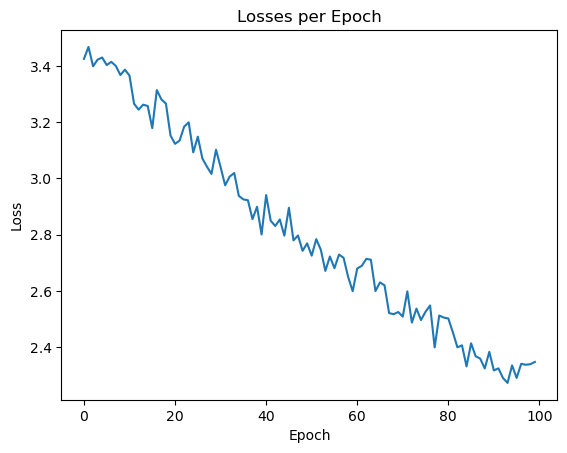

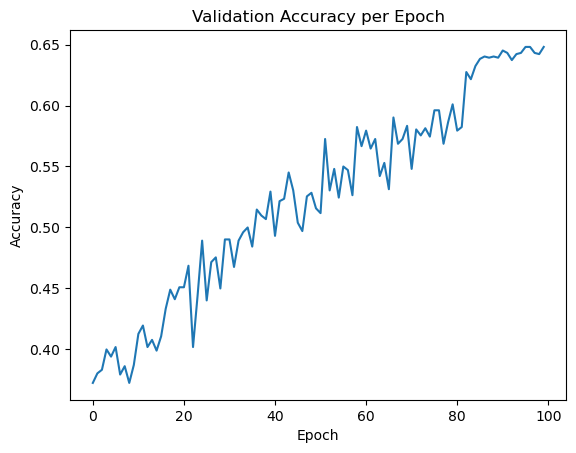

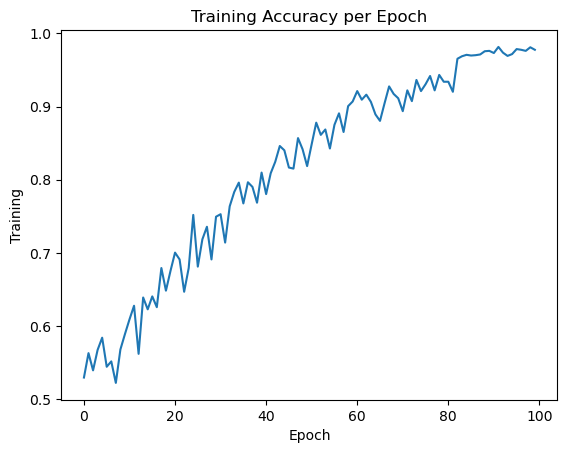

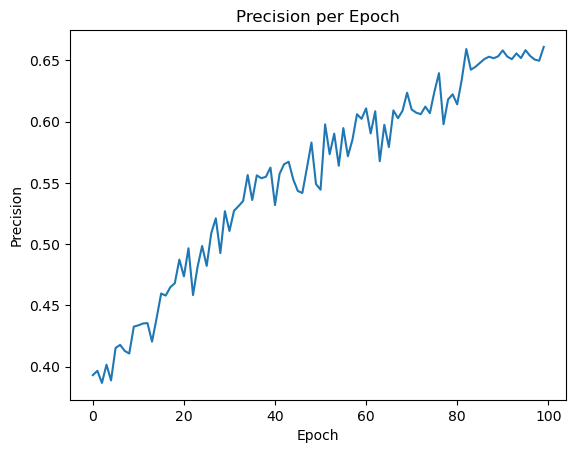

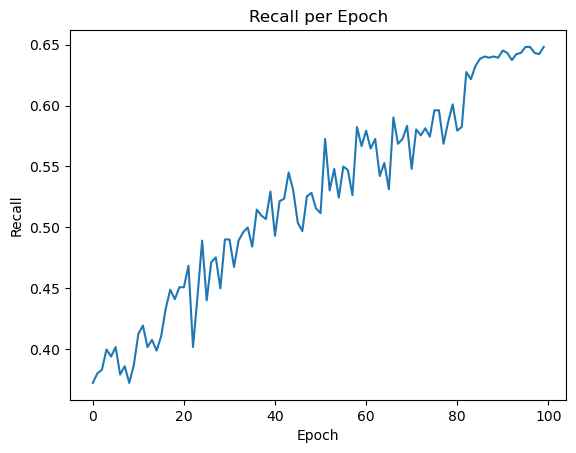

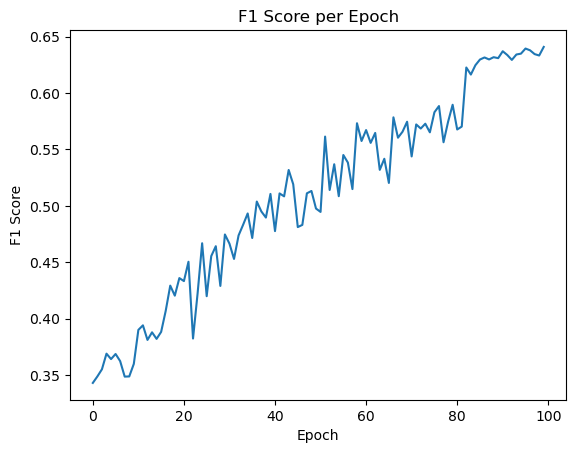

In [24]:
plt.plot(range(len(losses)), losses)
plt.title("Losses per Epoch")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.show()

plt.plot(range(len(valAccuracies)), valAccuracies)
plt.title("Validation Accuracy per Epoch")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.show()

plt.plot(range(len(trainAccuracies)), trainAccuracies)
plt.title("Training Accuracy per Epoch")
plt.ylabel("Training")
plt.xlabel("Epoch")
plt.show()

plt.plot(range(len(precisions)), precisions)
plt.title("Precision per Epoch")
plt.ylabel("Precision")
plt.xlabel("Epoch")
plt.show()

plt.plot(range(len(recalls)), recalls)
plt.title("Recall per Epoch")
plt.ylabel("Recall")
plt.xlabel("Epoch")
plt.show()

plt.plot(range(len(f1Scores)), f1Scores)
plt.title("F1 Score per Epoch")
plt.ylabel("F1 Score")
plt.xlabel("Epoch")
plt.show()

Calculate model accuracy

In [25]:
classifier.eval()

with torch.no_grad():
  correct = 0
  total = 0
  test_loader = DataLoader(flowersTest, batch_size=1)
  for images, labels in test_loader:
        images = images.to(device)
        predictions = classifier.forward(images)
        _, predictedClass = torch.max(predictions, dim=1)

        total += 1
        if predictedClass.item() == labels.item():
            correct += 1
  accuracy = correct / total
  print(f"Model Accuracy: {accuracy}")

Model Accuracy: 0.5794438120019515


Model's accuracy (on my run): 57.9% - Much better than the previous model.
Major differences in this model include the use of the selu activation function and an increase of dropout in the neural network.
Monitoring training accuracy indicated significant overfitting of the model - reducing this has improved the accuracy of it.
The model is still overfitting however, with a final training accuracy of 97%, so I can try to reduce overfitting again, which should hopefully yield even better results.

Due to monitoring training data, this model takes significantly longer to run - if rerunning for validation I would recommend you comment out code to calculate training accuracy. I also stopped the first training cycle manually after 65 epochs (due to PC performance issues), then continued training again for 100 more epochs.